# 监管模式
主要尝试下handoff模式

## 新魔法
- Annotated[MessagesState, InjectedState]:作为tool函数入参的类型时,这个InjectedState元数据修饰的参数不会发送给大模型,由框架注入state
- Annotated[str, InjectedToolCallId]:作为tool函数入参的类型时,这个InjectedToolCallId修饰的参数不会发送给模型,由框架注入toolcallid

In [1]:
from typing import Annotated
from langchain_core.tools import tool, InjectedToolCallId
from langgraph.prebuilt import InjectedState
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.types import Command

def create_handoff_tool(*, agent_name: str, description: str | None = None):
    """创建交接工具，用于将控制权转移给指定 Agent"""
    name = f"transfer_to_{agent_name}"
    description = description or f"Ask {agent_name} for help."

    @tool(name, description=description)
    def handoff_tool(
        state: Annotated[MessagesState, InjectedState],
        tool_call_id: Annotated[str, InjectedToolCallId],
    ) -> Command:
        tool_message = {
            "role": "tool",
            "content": f"Successfully transferred to {agent_name}",
            "name": name,
            "tool_call_id": tool_call_id,
        }
        return Command(
            goto=agent_name,                    # 目标 Agent 名称
            update={**state, "messages": state["messages"] + [tool_message]},
            graph=Command.PARENT,               # 在父图中导航
        )

    return handoff_tool

# 创建交接工具
assign_to_research_agent = create_handoff_tool(
    agent_name="research_agent",
    description="Assign task to a researcher agent.",
)

assign_to_math_agent = create_handoff_tool(
    agent_name="math_agent",
    description="Assign task to a math agent.",
)


[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="glm-4.7",
    api_key="d1de7475090740ebb6c887167a6a8b98.2WUSfYbmgQwYLKF4",
    base_url="https://open.bigmodel.cn/api/paas/v4/",  # 智谱OpenAI兼容地址，末尾斜杠不能丢
)


In [ ]:
# 创建research agent
from langchain_tavily import TavilySearch
from langchain.agents import create_agent

# 创建搜索工具
web_search = TavilySearch(
    max_results=3,
    tavily_api_key="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",
)

# 测试搜索工具
web_search_results = web_search.invoke("who is the mayor of NYC?")
print(web_search_results["results"][0]["content"])

research_agent = create_agent(
    model=llm,
    tools=[web_search],
    system_prompt=(
        "You are a research agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with research-related tasks, DO NOT do any math\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="research_agent",
)

The current mayor is Zohran Mamdani, who was elected on November 4, 2025, and took office shortly after midnight on January 1, 2026.

## History

[edit]

See also: List of mayors of New York City [...] | Seal of the City of New York |
| Flag of the mayor of New York City |
| Incumbent Zohran Mamdani since January 1, 2026 |
| Government of New York City |
| Style "Style (form of address)") | His Honor "Honour (style)"); Mr. Mayor (informal) |
| Residence | Gracie Mansion |
| Seat | New York City Hall |
| Term length | Four years, renewable once consecutively |
| Constituting instrument | New York City Charter |
| Inaugural holder | Thomas Willett | [...] of the mayor. Cornelius W. Lawrence, a Democrat, was elected that year.


In [4]:
# 创建mathagent
def add(a: float, b: float):
    """Add two numbers."""
    return a + b

def multiply(a: float, b: float):
    """Multiply two numbers."""
    return a * b

def divide(a: float, b: float):
    """Divide two numbers."""
    return a / b

math_agent = create_agent(
    model=llm,
    tools=[add, multiply, divide],
    system_prompt=(
        "You are a math agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with math-related tasks\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="math_agent",
)

In [ ]:
from langchain.agents import create_agent

supervisor_agent = create_agent(
    model=llm,
    tools=[assign_to_research_agent, assign_to_math_agent],
    system_prompt=(
        "You are a supervisor managing two agents:\n"
        "- a research agent. Assign research-related tasks to this agent\n"
        "- a math agent. Assign math-related tasks to this agent\n"
        "Assign work to one agent at a time, do not call agents in parallel.\n"
        "Do not do any work yourself."
        "涉及到数学计算,必须调用match agent"
    ),
    name="supervisor",
)

In [6]:
from langgraph.graph import END

# 定义多智能体 Supervisor 图
supervisor = (
    StateGraph(MessagesState)
    # 添加节点
    .add_node(supervisor_agent, destinations=("research_agent", "math_agent", END))
    .add_node(research_agent)
    .add_node(math_agent)
    # 添加边
    .add_edge(START, "supervisor")
    # Worker Agent 执行完毕后返回 Supervisor
    .add_edge("research_agent", "supervisor")
    .add_edge("math_agent", "supervisor")
    .compile()
)

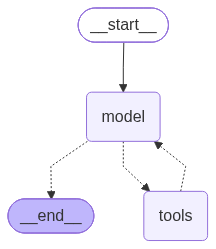

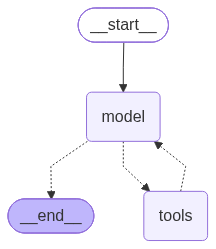

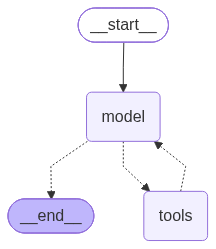

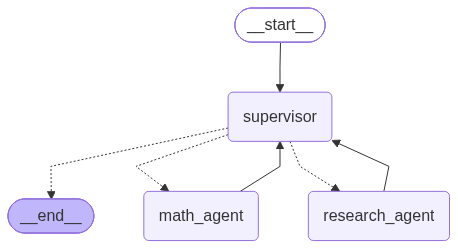

In [7]:
from IPython.display import display, Image
display(Image(math_agent.get_graph().draw_mermaid_png()))
display(Image(research_agent.get_graph().draw_mermaid_png()))
display(Image(supervisor_agent.get_graph().draw_mermaid_png()))
display(Image(supervisor.get_graph().draw_mermaid_png()))

In [ ]:

for chunk in supervisor.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "find US and New York state GDP in 2024. what % of US GDP was New York state?",
            }
        ]
    },
    subgraphs=True
):
    print(chunk)


{'supervisor': {'messages': [HumanMessage(content='find US and New York state GDP in 2024. what % of US GDP was New York state?', additional_kwargs={}, response_metadata={}, id='7766491a-3009-4833-b933-40421ac6c5fb'), AIMessage(content="I'll assign this research task to find the GDP data for the US and New York state in 2024.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 128, 'prompt_tokens': 268, 'total_tokens': 396, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 96, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 256}}, 'model_provider': 'openai', 'model_name': 'glm-4.7', 'system_fingerprint': None, 'id': '202608261521327dbd9d87f8f24e2b', 'finish_reason': 'tool_calls', 'logprobs': None}, name='supervisor', id='lc_run--01a03cf2-0367-73d3-b1d4-2d907153f198-0', tool_calls=[{'name': 'transfer_to_res

In [9]:
res = supervisor.invoke({
        "messages": [
            {
                "role": "user",
                "content": "find US and New York state GDP in 2024. what % of US GDP was New York state?",
            }
        ]
    })


In [11]:
import rich 
for msg in res["messages"]:
    msg.pretty_print()

================================ Human Message =================================

find US and New York state GDP in 2024. what % of US GDP was New York state?
================================== Ai Message ==================================
Name: supervisor

I'll assign this research task to find the 2024 GDP data for both the US and New York state, and then calculate the percentage.
Tool Calls:
  transfer_to_research_agent (call_-7314084113995005746)
 Call ID: call_-7314084113995005746
  Args:
================================= Tool Message =================================
Name: transfer_to_research_agent

Successfully transferred to research_agent
================================== Ai Message ==================================
Name: research_agent
Tool Calls:
  tavily_search (call_-7314043294625824597)
 Call ID: call_-7314043294625824597
  Args:
    query: US GDP 2024 New York state GDP 2024
================================= Tool Message =================================
Name: tavily_